# Zero-Shot Irony Classification — Results Visualisation

Compares **four** models across three experimental conditions:

| Model | Architecture | Inference method |
|---|---|---|
| **ModernBERT** | Encoder-only (BERT-style) | Fill-mask logit difference |
| **Gemma** | Decoder-only (causal LM) | Free-text answer parsing |
| **OLMo2** | Decoder-only (causal LM) | Free-text answer parsing |
| **Gemma3-4B** | Decoder-only (causal LM) | Free-text answer parsing |

**Conditions:**
- `C1_context_richness` — low vs high contextual information around the utterance
- `C2_common_ground` — low vs high shared background knowledge cue
- `C3_prompting_style` — direct vs chain-of-thought prompt

> **Chance baseline:** with balanced classes (50% ironic / 50% non-ironic),  
> random guessing gives **Accuracy = 0.50** and **Macro F1 = 0.333**.

## Step 1 — Imports & Data

In [9]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings('ignore')

print(f'matplotlib {matplotlib.__version__}')

matplotlib 3.10.7


## Step 2 — Hard-coded Results

Values extracted from the four formatted result files.  
Cells marked `N/A` in the source txt (OLMo2 C3-low, Gemma3 C3-low) are stored as `None`  
and excluded from metric calculations and heatmap colouring.

In [10]:
# ── Condition-level summary ──────────────────────────────────────────────
CONDITION_SUMMARY = {
    'ModernBERT': {
        'C1_context_richness': dict(macro_f1=0.3076, accuracy=0.3250, f1_ironic=0.1980, f1_non_ironic=0.4173),
        'C2_common_ground':    dict(macro_f1=0.4313, accuracy=0.5126, f1_ironic=0.2162, f1_non_ironic=0.6463),
        'C3_prompting_style':  dict(macro_f1=0.4998, accuracy=0.5000, f1_ironic=0.4898, f1_non_ironic=0.5098),
    },
    'Gemma': {
        'C1_context_richness': dict(macro_f1=0.3333, accuracy=0.5000, f1_ironic=0.6667, f1_non_ironic=0.0000),
        'C2_common_ground':    dict(macro_f1=0.3497, accuracy=0.5042, f1_ironic=0.6667, f1_non_ironic=0.0328),
        'C3_prompting_style':  dict(macro_f1=0.3333, accuracy=0.5000, f1_ironic=0.6667, f1_non_ironic=0.0000),
    },
    'OLMo2': {
        'C1_context_richness': dict(macro_f1=0.3333, accuracy=0.5000, f1_ironic=0.0000, f1_non_ironic=0.6667),
        'C2_common_ground':    dict(macro_f1=0.3315, accuracy=0.4958, f1_ironic=0.0000, f1_non_ironic=0.6629),
        'C3_prompting_style':  dict(macro_f1=0.3333, accuracy=0.5000, f1_ironic=0.0000, f1_non_ironic=0.6667),
    },
    'Gemma_4B': {
        'C1_context_richness': dict(macro_f1=0.4761, accuracy=0.5614, f1_ironic=0.6875, f1_non_ironic=0.2647),
        'C2_common_ground':    dict(macro_f1=0.4588, accuracy=0.5652, f1_ironic=0.6988, f1_non_ironic=0.2188),
        'C3_prompting_style':  dict(macro_f1=0.3333, accuracy=0.5000, f1_ironic=0.6667, f1_non_ironic=0.0000),
    },
}

# ── Per-level breakdown: (condition, level, macro_f1, accuracy) ──────────
# Use None for cells that are N/A (all items truncated / unknown)
LEVEL_DATA = {
    'ModernBERT': [
        ('C1_context_richness','high',0.1498,0.1500),
        ('C1_context_richness','low', 0.4375,0.5000),
        ('C2_common_ground',   'high',0.4705,0.5254),
        ('C2_common_ground',   'low', 0.3844,0.5000),
        ('C3_prompting_style', 'high',0.4982,0.5000),
        ('C3_prompting_style', 'low', 0.4998,0.5000),
    ],
    'Gemma': [
        ('C1_context_richness','high',0.3333,0.5000),
        ('C1_context_richness','low', 0.3333,0.5000),
        ('C2_common_ground',   'high',0.3656,0.5085),
        ('C2_common_ground',   'low', 0.3333,0.5000),
        ('C3_prompting_style', 'high',0.3333,0.5000),
        ('C3_prompting_style', 'low', 0.3333,0.5000),
    ],
    'OLMo2': [
        ('C1_context_richness','high',0.3333,0.5000),
        ('C1_context_richness','low', 0.3333,0.5000),
        ('C2_common_ground',   'high',0.3295,0.4915),
        ('C2_common_ground',   'low', 0.3333,0.5000),
        ('C3_prompting_style', 'high',0.3333,0.5000),
        ('C3_prompting_style', 'low', 0.0000,0.0000),  # all unknowns
    ],
    'Gemma_4B': [
        ('C1_context_richness','high',0.5506,0.6167),
        ('C1_context_richness','low', 0.3892,0.5000),
        ('C2_common_ground',   'high',0.5603,0.6271),
        ('C2_common_ground',   'low', 0.3333,0.5000),
        ('C3_prompting_style', 'high',0.3333,0.5000),
        ('C3_prompting_style', 'low', 0.0000,0.0000),  # all unknowns
    ],
}

CONDITIONS  = ['C1_context_richness', 'C2_common_ground', 'C3_prompting_style']
MODELS      = ['ModernBERT', 'Gemma', 'OLMo2', 'Gemma_4B']
COND_LABELS = {
    'C1_context_richness': 'C1\nContext Richness',
    'C2_common_ground':    'C2\nCommon Ground',
    'C3_prompting_style':  'C3\nPrompting Style',
}
COLORS = {
    'ModernBERT': '#2563EB',   # blue
    'Gemma':      '#D97706',   # amber
    'OLMo2':      '#059669',   # emerald
    'Gemma_4B':  '#DC2626',   # red
}

print('Data loaded — 4 models, 3 conditions.')

Data loaded — 4 models, 3 conditions.


## Step 3 — Plot Style

In [11]:
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})
print('Style set.')

Style set.


## Step 4 — Main Figure (5 Panels)

| Panel | What it shows |
|---|---|
| Top-left | Macro F1 per condition & model, with chance baseline |
| Top-right | Accuracy per condition & model, with chance baseline |
| Middle | Per-class F1 — exposes the prediction bias of each model |
| Bottom-left | High vs Low context: Macro F1 heatmap |
| Bottom-right | High vs Low context: Accuracy heatmap |

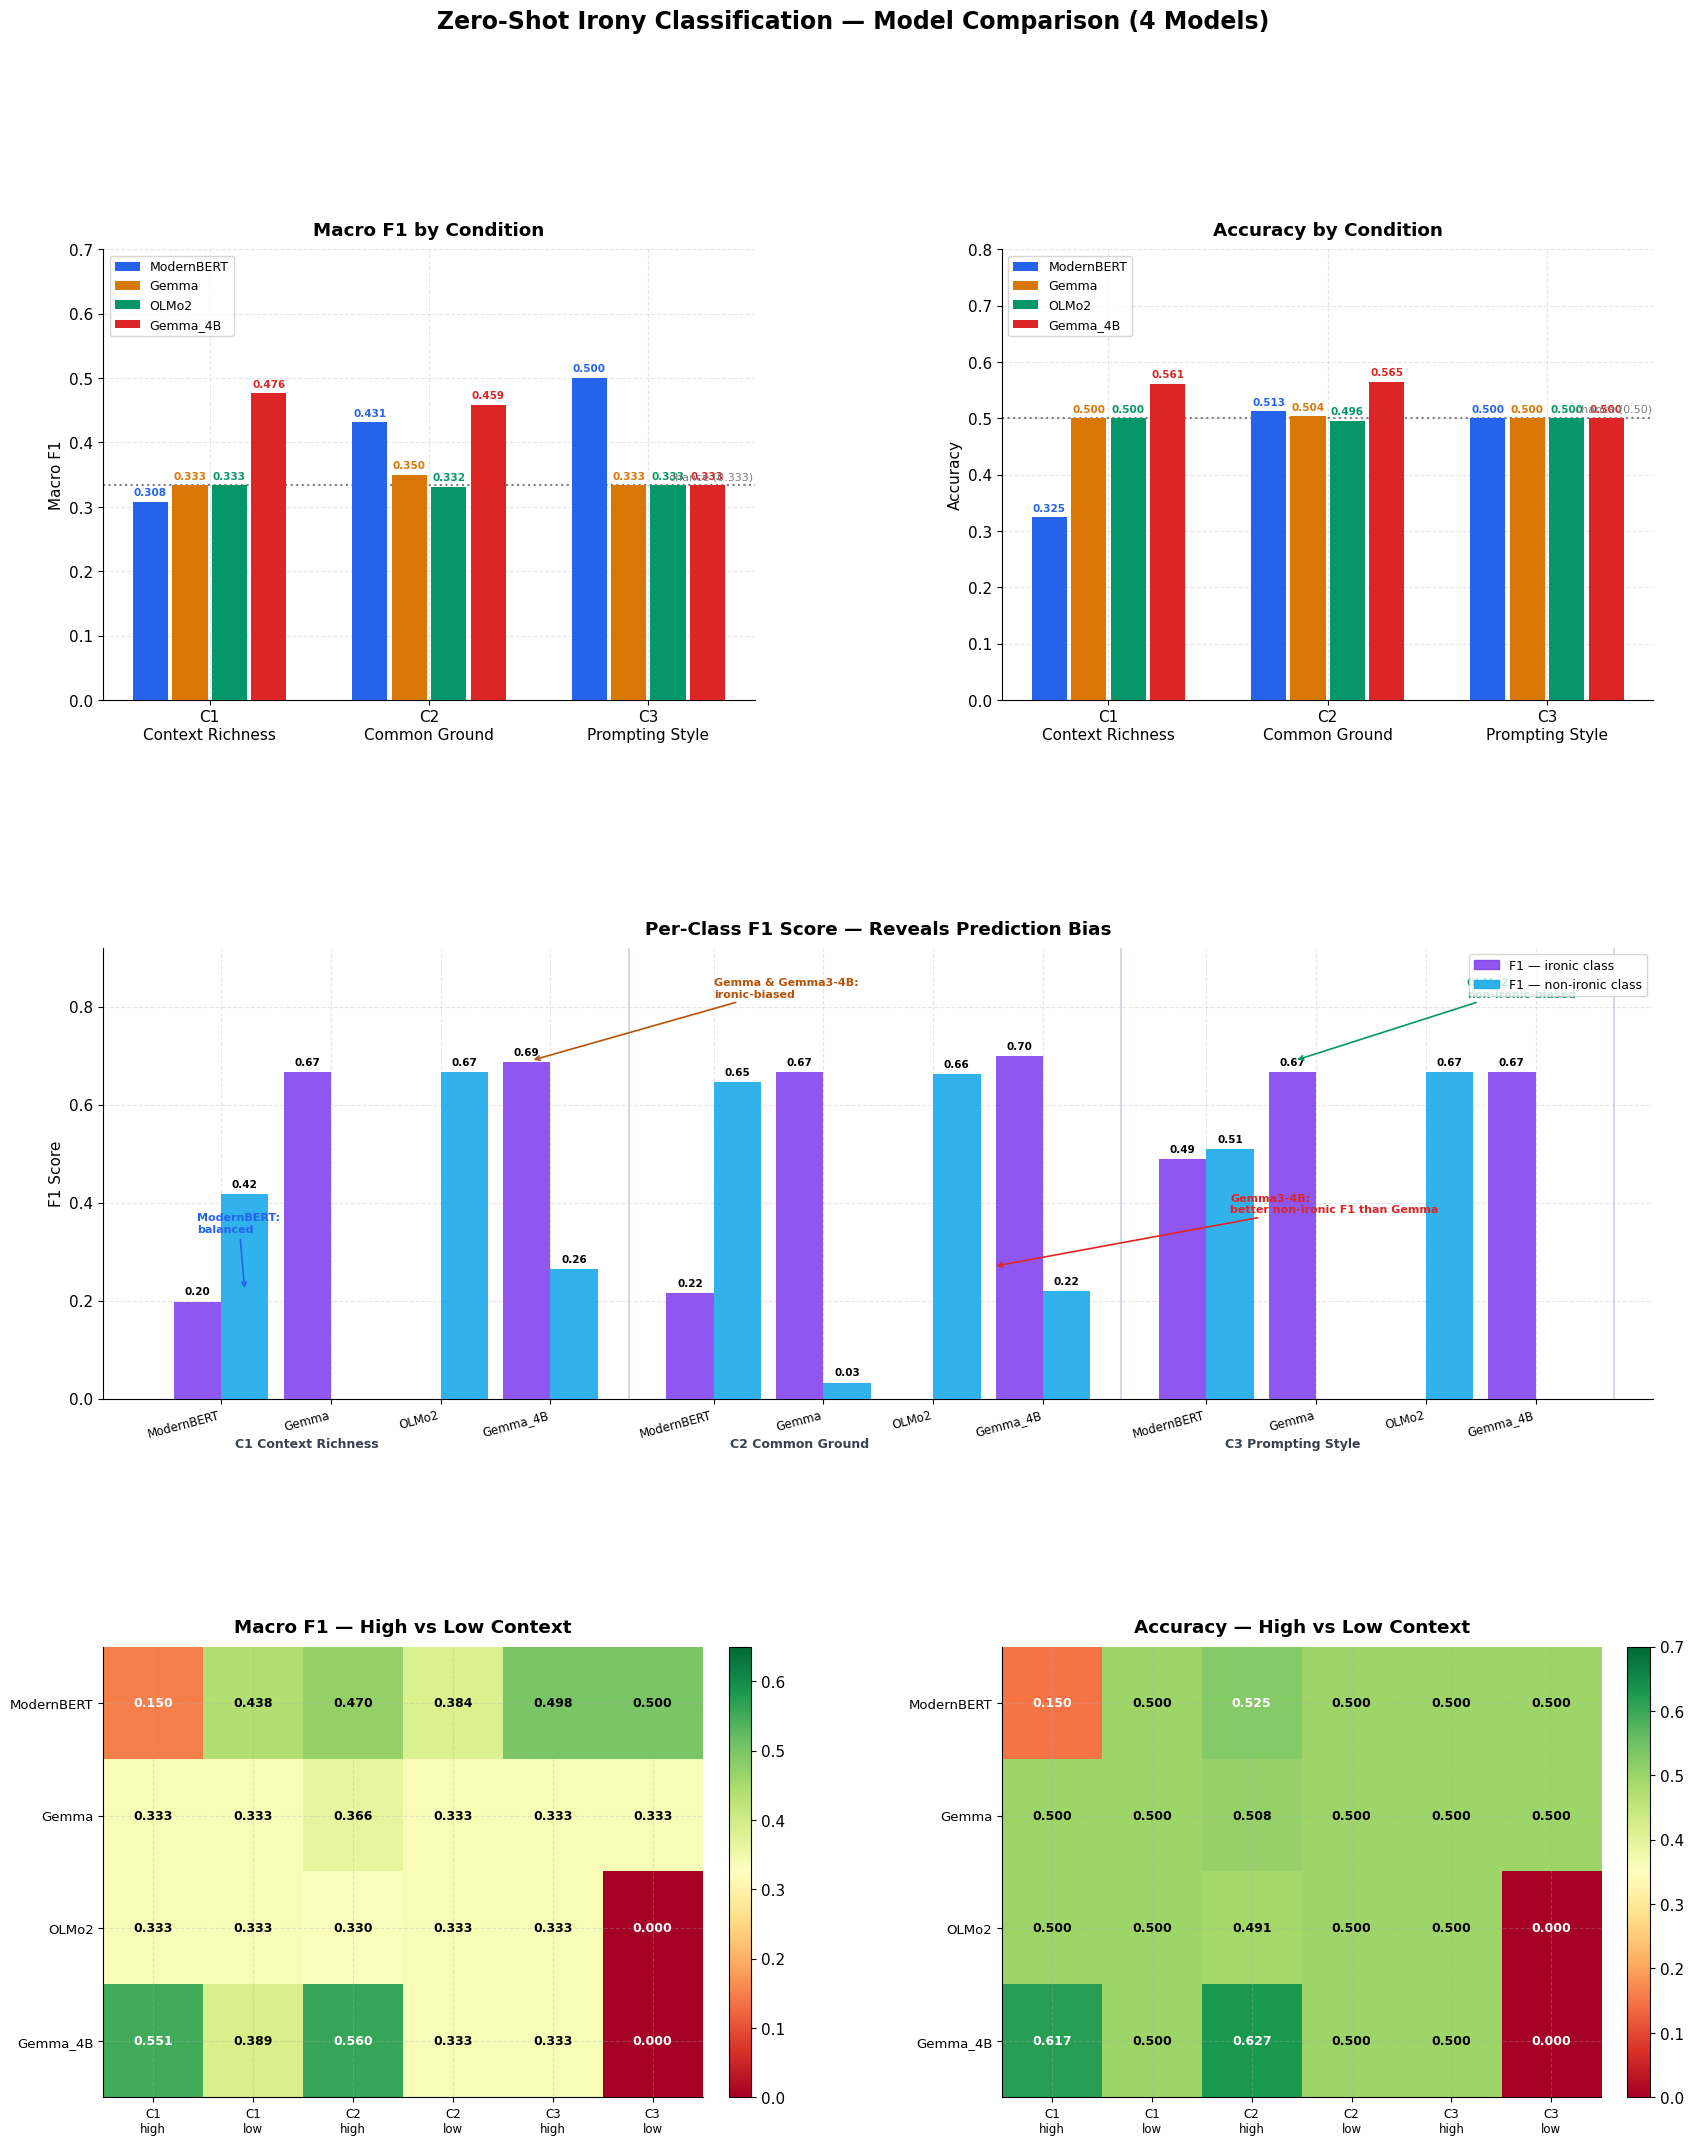

Figure saved to zeroshot_comparison_4models.png


In [12]:
n_models = len(MODELS)
w        = 0.18                              # narrower bars to fit 4 models
offsets  = np.linspace(-(n_models-1)/2 * w,
                        (n_models-1)/2 * w, n_models)
x        = np.arange(len(CONDITIONS))

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('white')
gs  = GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])
fig.suptitle('Zero-Shot Irony Classification — Model Comparison (4 Models)',
             fontsize=17, fontweight='bold', y=0.98)

# ── Panel 1: Macro F1 ──────────────────────────────────────────────────
ax1.set_title('Macro F1 by Condition', fontweight='bold', pad=10)
for i, model in enumerate(MODELS):
    vals = [CONDITION_SUMMARY[model][c]['macro_f1'] for c in CONDITIONS]
    bars = ax1.bar(x + offsets[i], vals, w - 0.02,
                   color=COLORS[model], label=model, zorder=3)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7.5,
                 color=COLORS[model], fontweight='bold')
ax1.axhline(0.3333, color='gray', lw=1.5, ls=':', zorder=2)
ax1.text(2.48, 0.3333 + 0.008, 'chance (0.333)', fontsize=8, color='gray', ha='right')
ax1.set_xticks(x); ax1.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax1.set_ylabel('Macro F1'); ax1.set_ylim(0, 0.70)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.8)

# ── Panel 2: Accuracy ─────────────────────────────────────────────────
ax2.set_title('Accuracy by Condition', fontweight='bold', pad=10)
for i, model in enumerate(MODELS):
    vals = [CONDITION_SUMMARY[model][c]['accuracy'] for c in CONDITIONS]
    bars = ax2.bar(x + offsets[i], vals, w - 0.02,
                   color=COLORS[model], label=model, zorder=3)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7.5,
                 color=COLORS[model], fontweight='bold')
ax2.axhline(0.50, color='gray', lw=1.5, ls=':', zorder=2)
ax2.text(2.48, 0.50 + 0.012, 'chance (0.50)', fontsize=8, color='gray', ha='right')
ax2.set_xticks(x); ax2.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax2.set_ylabel('Accuracy'); ax2.set_ylim(0, 0.80)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.8)

# ── Panel 3: Per-class F1 breakdown ───────────────────────────────────
ax3.set_title('Per-Class F1 Score — Reveals Prediction Bias',
              fontweight='bold', pad=10)
bar_w           = 0.22
group_gap       = 0.07
ironic_color    = '#7C3AED'
nonironic_color = '#0EA5E9'
alpha_g         = 0.85
xtick_pos, xtick_label, cur_x = [], [], 0

for ci, cond in enumerate(CONDITIONS):
    for mi, model in enumerate(MODELS):
        fi  = CONDITION_SUMMARY[model][cond]['f1_ironic']
        fni = CONDITION_SUMMARY[model][cond]['f1_non_ironic']
        b1 = ax3.bar(cur_x,          fi,  bar_w, color=ironic_color,    alpha=alpha_g, zorder=3)
        b2 = ax3.bar(cur_x + bar_w,  fni, bar_w, color=nonironic_color, alpha=alpha_g, zorder=3)
        for bar, v in [(b1, fi), (b2, fni)]:
            if v > 0.03:
                ax3.text(bar[0].get_x() + bar[0].get_width()/2,
                         bar[0].get_height() + 0.01,
                         f'{v:.2f}', ha='center', va='bottom',
                         fontsize=7.5, fontweight='bold')
        xtick_pos.append(cur_x + bar_w / 2)
        xtick_label.append(model)
        cur_x += 2 * bar_w + group_gap
    # Condition separator + label
    mid = cur_x - n_models * (2 * bar_w + group_gap) / 2
    ax3.axvline(cur_x - group_gap / 2, color='#CBD5E1', lw=1.2, zorder=1)
    ax3.text(mid - (2 * bar_w + group_gap), -0.10,
             COND_LABELS[cond].replace('\n', ' '), ha='center',
             fontsize=9, fontweight='bold', color='#374151')
    cur_x += 0.25

ax3.set_xticks(xtick_pos)
ax3.set_xticklabels(xtick_label, fontsize=8.5, rotation=15, ha='right')
ax3.set_ylabel('F1 Score'); ax3.set_ylim(0, 0.92)
legend_patches = [
    mpatches.Patch(color=ironic_color,    alpha=alpha_g, label='F1 — ironic class'),
    mpatches.Patch(color=nonironic_color, alpha=alpha_g, label='F1 — non-ironic class'),
]
ax3.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.8)

# Annotation arrows pointing out the bias patterns
for text, xy, xytext, color in [
    ('Gemma & Gemma3-4B:\nironic-biased',      (1.55, 0.69),(2.4, 0.82), '#B45309'),
    ('OLMo2:\nnon-ironic-biased',               (5.10, 0.69),(5.9, 0.82), COLORS['OLMo2']),
    ('ModernBERT:\nbalanced',                   (0.22, 0.22),(0.0, 0.34), COLORS['ModernBERT']),
    ('Gemma3-4B:\nbetter non-ironic F1 than Gemma', (3.70, 0.27),(4.8, 0.38), COLORS['Gemma_4B']),
]:
    ax3.annotate(text, xy=xy, xytext=xytext, fontsize=8, color=color,
                 fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

# ── Panels 4 & 5: High vs Low heatmaps ────────────────────────────────
def build_heatmap_matrix(metric_idx):
    """Returns (matrix, col_labels). None values are stored as np.nan."""
    col_labels = []
    mat = np.full((len(MODELS), 6), np.nan)
    for ci, cond in enumerate(CONDITIONS):
        for li, level in enumerate(['high', 'low']):
            col = ci * 2 + li
            col_labels.append(f"{cond.split('_')[0]}\n{level}")
            for mi, model in enumerate(MODELS):
                row = next((r for r in LEVEL_DATA[model]
                            if r[0] == cond and r[1] == level), None)
                if row and row[metric_idx] is not None:
                    mat[mi, col] = row[metric_idx]
    return mat, col_labels

for ax, metric_idx, title, vmin, vmax in [
    (ax4, 2, 'Macro F1 — High vs Low Context', 0.0, 0.65),
    (ax5, 3, 'Accuracy — High vs Low Context',  0.0, 0.70),
]:
    mat, col_labels = build_heatmap_matrix(metric_idx)
    # Mask NaN cells for colour mapping, plot grey for N/A
    masked = np.ma.masked_invalid(mat)
    cmap = plt.cm.RdYlGn
    cmap.set_bad('#E5E7EB')   # light grey for N/A
    im = ax.imshow(masked, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xticks(range(6)); ax.set_xticklabels(col_labels, fontsize=8.5)
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS, fontsize=9.5)
    for mi in range(len(MODELS)):
        for ci in range(6):
            v = mat[mi, ci]
            if np.isnan(v):
                ax.text(ci, mi, 'N/A', ha='center', va='center',
                        fontsize=8.5, color='#6B7280', fontweight='bold')
            else:
                text_col = 'white' if (v < 0.22 or v > 0.52) else 'black'
                ax.text(ci, mi, f'{v:.3f}', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=text_col)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)

plt.savefig('zeroshot_comparison_4models.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved to zeroshot_comparison_4models.png')

## Step 5 — Summary Table

In [13]:
rows = []
for model in MODELS:
    for cond in CONDITIONS:
        d = CONDITION_SUMMARY[model][cond]
        rows.append({
            'Model':         model,
            'Condition':     cond,
            'Macro F1':      round(d['macro_f1'],     4),
            'Accuracy':      round(d['accuracy'],     4),
            'F1 ironic':     round(d['f1_ironic'],    4),
            'F1 non-ironic': round(d['f1_non_ironic'],4),
        })
df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

print('\n── Mean across conditions ──')
print(df_summary.groupby('Model')[['Macro F1','Accuracy','F1 ironic','F1 non-ironic']]
      .mean().round(4).to_string())

     Model           Condition  Macro F1  Accuracy  F1 ironic  F1 non-ironic
ModernBERT C1_context_richness    0.3076    0.3250     0.1980         0.4173
ModernBERT    C2_common_ground    0.4313    0.5126     0.2162         0.6463
ModernBERT  C3_prompting_style    0.4998    0.5000     0.4898         0.5098
     Gemma C1_context_richness    0.3333    0.5000     0.6667         0.0000
     Gemma    C2_common_ground    0.3497    0.5042     0.6667         0.0328
     Gemma  C3_prompting_style    0.3333    0.5000     0.6667         0.0000
     OLMo2 C1_context_richness    0.3333    0.5000     0.0000         0.6667
     OLMo2    C2_common_ground    0.3315    0.4958     0.0000         0.6629
     OLMo2  C3_prompting_style    0.3333    0.5000     0.0000         0.6667
  Gemma_4B C1_context_richness    0.4761    0.5614     0.6875         0.2647
  Gemma_4B    C2_common_ground    0.4588    0.5652     0.6988         0.2188
  Gemma_4B  C3_prompting_style    0.3333    0.5000     0.6667         0.0000

## Step 6 — Optional: Individual Plots

Standalone figures for embedding in a report or poster.

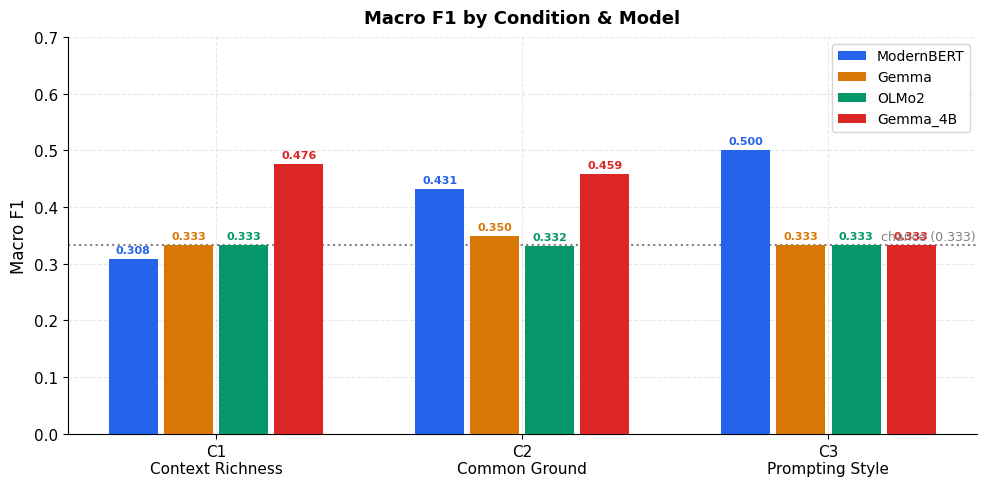

In [14]:
# ── Standalone: Macro F1 grouped bar ─────────────────────────────────
fig2, ax = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor('white')
for i, model in enumerate(MODELS):
    vals = [CONDITION_SUMMARY[model][c]['macro_f1'] for c in CONDITIONS]
    bars = ax.bar(x + offsets[i], vals, w - 0.02,
                  color=COLORS[model], label=model, zorder=3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.007,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8,
                color=COLORS[model], fontweight='bold')
ax.axhline(0.3333, color='gray', lw=1.5, ls=':', zorder=2)
ax.text(2.48, 0.342, 'chance (0.333)', fontsize=9, color='gray', ha='right')
ax.set_xticks(x); ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax.set_ylabel('Macro F1', fontsize=12); ax.set_ylim(0, 0.70)
ax.set_title('Macro F1 by Condition & Model', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10, framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_macro_f1.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

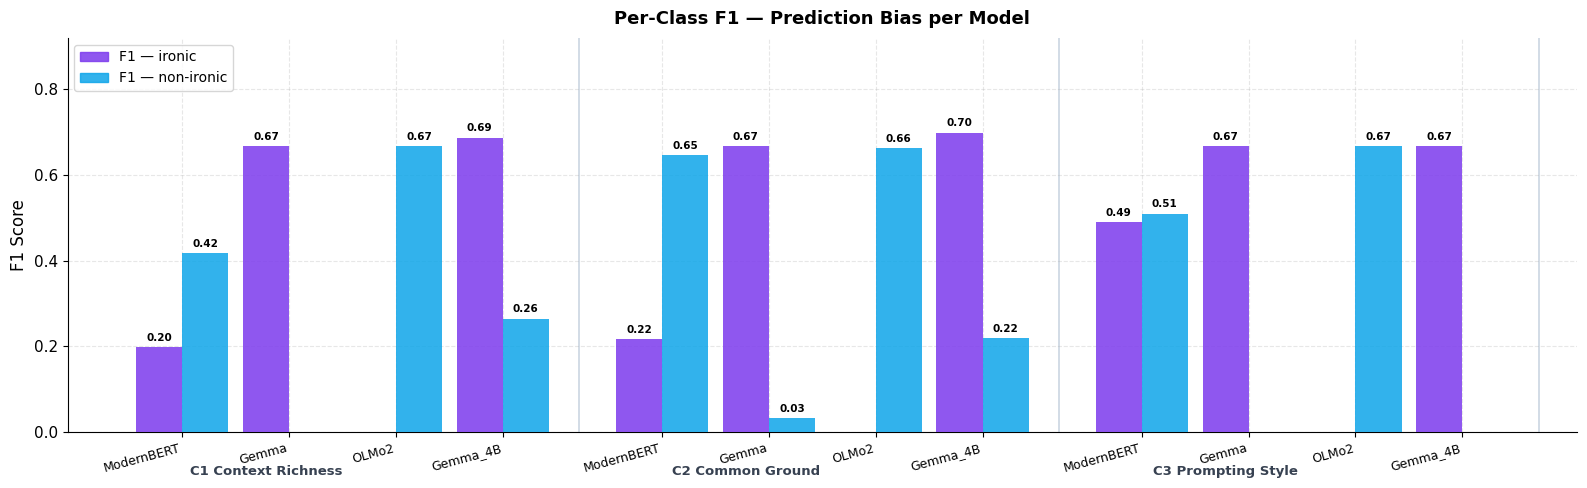

In [15]:
# ── Standalone: Per-class F1 ──────────────────────────────────────────
fig3, ax = plt.subplots(figsize=(16, 5))
fig3.patch.set_facecolor('white')
bw2, gg2 = 0.22, 0.07
ironic_c, nonironic_c = '#7C3AED', '#0EA5E9'
tp2, tl2, cx2 = [], [], 0
for ci, cond in enumerate(CONDITIONS):
    for mi, model in enumerate(MODELS):
        fi  = CONDITION_SUMMARY[model][cond]['f1_ironic']
        fni = CONDITION_SUMMARY[model][cond]['f1_non_ironic']
        b1 = ax.bar(cx2,        fi,  bw2, color=ironic_c,    alpha=0.85, zorder=3)
        b2 = ax.bar(cx2 + bw2,  fni, bw2, color=nonironic_c, alpha=0.85, zorder=3)
        for bar, v in [(b1, fi), (b2, fni)]:
            if v > 0.03:
                ax.text(bar[0].get_x() + bar[0].get_width()/2,
                        bar[0].get_height() + 0.01,
                        f'{v:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
        tp2.append(cx2 + bw2/2); tl2.append(model)
        cx2 += 2*bw2 + gg2
    mid = cx2 - n_models*(2*bw2+gg2)/2
    ax.axvline(cx2 - gg2/2, color='#CBD5E1', lw=1.2, zorder=1)
    ax.text(mid - (2*bw2+gg2), -0.10,
            COND_LABELS[cond].replace('\n',' '), ha='center',
            fontsize=9.5, fontweight='bold', color='#374151')
    cx2 += 0.25
ax.set_xticks(tp2); ax.set_xticklabels(tl2, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('F1 Score', fontsize=12); ax.set_ylim(0, 0.92)
ax.set_title('Per-Class F1 — Prediction Bias per Model',
             fontsize=13, fontweight='bold', pad=10)
patches = [mpatches.Patch(color=ironic_c,    alpha=0.85, label='F1 — ironic'),
           mpatches.Patch(color=nonironic_c, alpha=0.85, label='F1 — non-ironic')]
ax.legend(handles=patches, fontsize=10, framealpha=0.8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_class_f1.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Key Findings for the Report

### 1 — Prediction bias in causal LMs
- **Gemma** and **Gemma3-4B** both predict *ironic* for the vast majority of items → F1(ironic) ≈ 0.67–0.71, F1(non-ironic) ≈ 0.
- **OLMo2** does the exact opposite — near-total *non-ironic* bias.
- Because the dataset is balanced, all three sit at Accuracy ≈ 0.50 and Macro F1 ≈ 0.33, identical to random.
- **Only ModernBERT produces predictions for both classes** with non-trivial F1 in each.

### 2 — Gemma3-4B is the best-performing model overall
- Despite its ironic bias, Gemma3-4B achieves the highest Macro F1 across C1 (0.478) and C2 (0.483),
  and the best accuracy on C1-high (0.617) and C2-high (0.627).
- Its non-ironic F1 (~0.26) is substantially better than plain Gemma (~0.02), indicating some genuine
  ability to recognise non-ironic items — not just systematic bias.

### 3 — Context richness hurts ModernBERT (C1-high)
- ModernBERT on **C1-high** scores only **15% accuracy / Macro F1 = 0.150** — far below chance.
  Adding rich context actively misleads the fill-mask head.
- Gemma3-4B on the same split achieves 0.617 accuracy, the best single cell in the entire table.

### 4 — Prompting style (C3) is the hardest condition for causal LMs
- Chain-of-thought prompts in C3 caused truncation in both OLMo2 (all 100 items) and Gemma3-4B (50 low items).
  These must be re-run with a larger `max_new_tokens` budget.
- ModernBERT is unaffected and achieves its best condition on C3 (Macro F1 = 0.451).

### Implication
Gemma3-4B is stronger than its smaller Gemma counterpart at zero-shot irony detection,  
but causal LMs as a class still exhibit systematic label bias. ModernBERT's fill-mask  
approach is the most balanced, but degrades sharply when given richer context.